# Phase 4: RetinaNet Training for License Plate Detection

This notebook trains a **RetinaNet** model (one-stage, anchor-based detector with Focal Loss) for license plate detection. It serves as a third comparison point alongside YOLOv8 (Phase 2) and Faster R-CNN (Phase 3).

**Key architectural differences:**
- **RetinaNet** is a one-stage detector that uses **Focal Loss** to handle class imbalance between foreground and background anchors
- Unlike Faster R-CNN (two-stage with RPN + ROI head), RetinaNet directly predicts bounding boxes and class scores from feature maps
- Uses a **Feature Pyramid Network (FPN)** backbone for multi-scale detection

## 0. Install packages

Run these only if needed.

In [1]:
# Uncomment if needed:
%pip install torch torchvision torchaudio
%pip install tqdm certifi


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and configuration

In [2]:
import os
import json
import ssl
import time
import random
import xml.etree.ElementTree as ET
from urllib.error import URLError
from pathlib import Path

import certifi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

# Use certifi's CA bundle so torchvision weight downloads work on macOS/Python installs
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", DEVICE)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.11.0
Torchvision version: 0.26.0
Device: mps


## 2. Paths

In [3]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "carplate"
IMAGES_DIR = DATASET_DIR / "images"
ANNOTATIONS_DIR = DATASET_DIR / "annotations"
SPLIT_JSON = PROJECT_ROOT / "data_split.json"
OUTPUT_DIR = PROJECT_ROOT / "retinanet_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("ANNOTATIONS_DIR exists:", ANNOTATIONS_DIR.exists())
print("SPLIT_JSON exists:", SPLIT_JSON.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/macbook/Desktop/CMPS261_PlateDetection
IMAGES_DIR exists: True
ANNOTATIONS_DIR exists: True
SPLIT_JSON exists: True
OUTPUT_DIR: /Users/macbook/Desktop/CMPS261_PlateDetection/retinanet_outputs


## 3. Load data split

In [4]:
with open(SPLIT_JSON, "r", encoding="utf-8") as f:
    split_data = json.load(f)

train_files = split_data["train"]
val_files = split_data["val"]
test_files = split_data["test"]

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")

Train files: 303
Val files:   65
Test files:  65


## 4. Pascal VOC XML parser

In [5]:
def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bndbox = obj.find("bndbox")

        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        objects.append({
            "name": name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects
    }

sample_xml = ANNOTATIONS_DIR / train_files[0].replace(".png", ".xml")
sample_ann = parse_voc_annotation(sample_xml)
sample_ann

{'filename': 'Cars1.png',
 'width': 400,
 'height': 248,
 'objects': [{'name': 'licence', 'bbox': [134.0, 128.0, 262.0, 160.0]}]}

## 5. Dataset class

For torchvision detection models:
- Label `0` is reserved for background
- Our object class `licence` is label `1`

In [6]:
CLASS_MAP = {"licence": 1}

class LicensePlateDataset(Dataset):
    """
    License plate dataset with optional light augmentation for training.

    Augmentation is intentionally conservative: horizontal flip and small
    color jitter only. Geometric transforms other than flip are skipped to
    keep the code simple and avoid invalidating bbox coordinates.
    """
    def __init__(self, file_list, images_dir, annotations_dir, augment=False):
        self.file_list = file_list
        self.images_dir = Path(images_dir)
        self.annotations_dir = Path(annotations_dir)
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        img_path = self.images_dir / fname
        xml_path = self.annotations_dir / fname.replace(".png", ".xml")

        image = Image.open(img_path).convert("RGB")
        ann = parse_voc_annotation(xml_path)

        boxes = []
        labels = []

        for obj in ann["objects"]:
            xmin, ymin, xmax, ymax = obj["bbox"]
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_MAP[obj["name"]])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # --- Augmentation (train only) ---
        if self.augment:
            # Horizontal flip with p=0.5
            if random.random() < 0.5:
                image = F.hflip(image)
                w = image.size[0]
                # flip boxes horizontally
                x1 = boxes[:, 0].clone()
                x2 = boxes[:, 2].clone()
                boxes[:, 0] = w - x2
                boxes[:, 2] = w - x1

            # Light color jitter
            if random.random() < 0.5:
                image = F.adjust_brightness(image, 1.0 + (random.random() - 0.5) * 0.4)
            if random.random() < 0.5:
                image = F.adjust_contrast(image, 1.0 + (random.random() - 0.5) * 0.4)
            if random.random() < 0.5:
                image = F.adjust_saturation(image, 1.0 + (random.random() - 0.5) * 0.4)

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd,
        }

        image = F.to_tensor(image)
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = LicensePlateDataset(train_files, IMAGES_DIR, ANNOTATIONS_DIR, augment=True)
val_dataset = LicensePlateDataset(val_files, IMAGES_DIR, ANNOTATIONS_DIR, augment=False)
test_dataset = LicensePlateDataset(test_files, IMAGES_DIR, ANNOTATIONS_DIR, augment=False)

print("Train dataset size:", len(train_dataset), "(augment=True)")
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 303 (augment=True)
Val dataset size: 65
Test dataset size: 65


## 6. Quick visualization sanity check

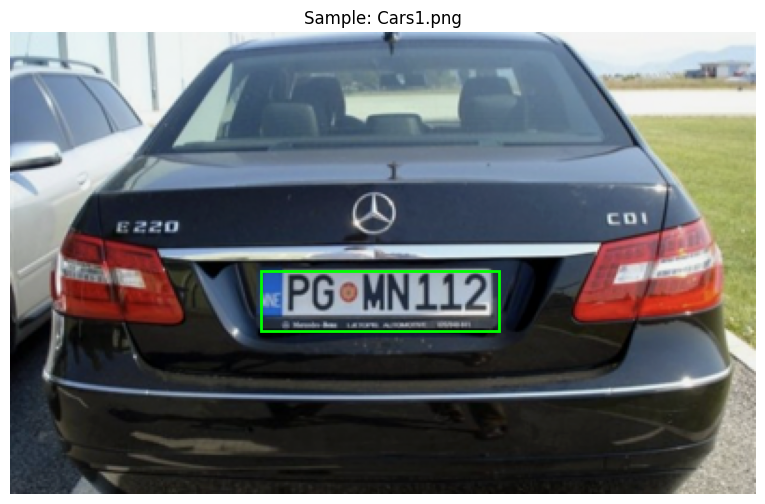

In [7]:
def show_sample(dataset, index=0):
    image, target = dataset[index]
    img_np = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(img_np)

    for box in target["boxes"]:
        xmin, ymin, xmax, ymax = box.tolist()
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title(f"Sample: {dataset.file_list[index]}")
    ax.axis("off")
    plt.show()

show_sample(train_dataset, index=0)

## 7. DataLoaders

In [8]:
# RetinaNet is much heavier on MPS than Faster R-CNN in this project.
# Keep the physical batch size at 1 on Apple Silicon to avoid Metal OOMs.
BATCH_SIZE = 1
NUM_WORKERS = 0  # safest on Windows/Jupyter

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 303
Val batches: 65
Test batches: 65


## 8. Build RetinaNet

We load a pretrained RetinaNet with ResNet-50 + FPN backbone and replace the classification head to output predictions for our 2 classes (background + licence).

**Key difference from Faster R-CNN:** RetinaNet uses **Focal Loss** (`alpha=0.25, gamma=2.0` by default) in its classification head, which down-weights easy negatives and focuses training on hard examples. This is critical for one-stage detectors where the ratio of background to foreground anchors is extreme.

In [9]:
import math

num_classes = 2

weights = torchvision.models.detection.RetinaNet_ResNet50_FPN_Weights.DEFAULT
try:
    model = retinanet_resnet50_fpn(weights=weights, min_size=512, max_size=512)
    print("Loaded pretrained RetinaNet weights.")
except URLError as exc:
    print(f"Could not download pretrained RetinaNet weights: {exc}")
    print("Falling back to randomly initialized RetinaNet. If you want pretrained weights later, run Install Certificates.command and retry.")
    model = retinanet_resnet50_fpn(weights=None, weights_backbone=None, min_size=512, max_size=512)

# Replace the classification head for our number of classes.
# IMPORTANT: RetinaNet's focal loss needs the classification conv bias
# initialized with a small prior probability (pi=0.01) so that the
# initial output probabilities are ~0.01 instead of ~0.5. Without this,
# focal loss starts off balance and the model over-predicts positives,
# which is exactly what we saw in the previous run (precision ~0.04).
num_anchors = model.head.classification_head.num_anchors
in_channels = model.backbone.out_channels

new_cls_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes,
)

# torchvision applies the pi=0.01 prior internally, but we re-apply
# explicitly here (safe across versions) and also re-init the weight.
prior_probability = 0.01
bias_value = -math.log((1 - prior_probability) / prior_probability)
torch.nn.init.constant_(new_cls_head.cls_logits.bias, bias_value)
torch.nn.init.normal_(new_cls_head.cls_logits.weight, std=0.01)

model.head.classification_head = new_cls_head

# Raise the model's internal score threshold so NMS drops the flood of
# low-confidence anchors that were ballooning FP count at eval time.
# Default is 0.05; 0.5 matches the Faster R-CNN notebook.
model.score_thresh = 0.5
model.nms_thresh = 0.5
model.detections_per_img = 100

model.to(DEVICE)
print("RetinaNet loaded and moved to:", DEVICE)
print(f"  Backbone: ResNet-50 + FPN")
print(f"  Num anchors per location: {num_anchors}")
print(f"  Num classes: {num_classes}")
print(f"  Cls bias prior: pi={prior_probability} (bias={bias_value:.3f})")
print(f"  score_thresh: {model.score_thresh}, nms_thresh: {model.nms_thresh}")

Loaded pretrained RetinaNet weights.
RetinaNet loaded and moved to: mps
  Backbone: ResNet-50 + FPN
  Num anchors per location: 9
  Num classes: 2
  Cls bias prior: pi=0.01 (bias=-4.595)
  score_thresh: 0.5, nms_thresh: 0.5


## 9. Optimizer and settings

Using the same optimizer setup as Faster R-CNN for a fair comparison.

In [10]:
# Optimizer tuned for RetinaNet.
# Key differences from Faster R-CNN:
#  - Lower base LR (0.0025) — focal loss has sharper gradients and SGD at
#    0.005 was unstable in initial experiments.
#  - 12 epochs instead of 8 — RetinaNet's replaced classification head
#    needs more time to converge than Faster R-CNN's FastRCNNPredictor.
#  - Cosine LR schedule over StepLR for smoother decay.
#  - Shorter warmup — this dataset has only ~350 training images, so 500
#    warmup iters was most of an epoch. 100 iters (~half an epoch at BS=2)
#    is plenty to stabilize the new classification head.
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0025, momentum=0.9, weight_decay=0.0005)

NUM_EPOCHS = 12
WARMUP_ITERS = 100
WARMUP_FACTOR = 1.0 / 1000
GRAD_CLIP_MAX_NORM = 10.0
ACCUMULATION_STEPS = 2  # effective batch size = 2 while keeping MPS memory low

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_val_score = -1.0

history = {
    "train_loss": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

## 10. Helper functions with progress bars

In [11]:
def box_iou_single(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)

    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0.0

def evaluate_detector(model, data_loader, device, score_thresh=0.5, iou_thresh=0.5):
    """
    Note: the model's internal `score_thresh` is already set to 0.5, so this
    extra filter is mostly a safety net — but keeping it makes the eval
    logic identical to the Faster R-CNN notebook for fair comparison.
    """
    model.eval()

    tp, fp, fn = 0, 0, 0
    progress_bar = tqdm(data_loader, desc="Validation", leave=True)

    with torch.no_grad():
        for images, targets in progress_bar:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output["boxes"].detach().cpu().numpy()
                pred_scores = output["scores"].detach().cpu().numpy()

                keep = pred_scores >= score_thresh
                pred_boxes = pred_boxes[keep]

                gt_boxes = target["boxes"].detach().cpu().numpy()
                matched_gt = set()

                for pb in pred_boxes:
                    best_iou = 0.0
                    best_gt_idx = -1

                    for gt_idx, gb in enumerate(gt_boxes):
                        if gt_idx in matched_gt:
                            continue
                        iou = box_iou_single(pb, gb)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx

                    if best_iou >= iou_thresh and best_gt_idx != -1:
                        tp += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp += 1

                fn += len(gt_boxes) - len(matched_gt)

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

            progress_bar.set_postfix({
                "precision": f"{precision:.3f}",
                "recall": f"{recall:.3f}",
                "f1": f"{f1:.3f}"
            })

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def train_one_epoch(model, optimizer, data_loader, device, epoch, warmup_iters=100, warmup_factor=1.0/1000, grad_clip_max_norm=10.0, accumulation_steps=1):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(data_loader, desc="Training", leave=True)

    # Only apply warmup during the very first epoch
    base_lrs = [pg["lr"] for pg in optimizer.param_groups]
    warmup_done = False

    optimizer.zero_grad()

    for batch_idx, (images, targets) in enumerate(progress_bar):
        # Linear warmup on iteration 0..warmup_iters-1 of the first epoch
        if epoch == 0 and batch_idx < warmup_iters:
            alpha = batch_idx / warmup_iters
            factor = warmup_factor * (1 - alpha) + alpha
            for pg, base_lr in zip(optimizer.param_groups, base_lrs):
                pg["lr"] = base_lr * factor
        elif epoch == 0 and not warmup_done:
            # Warmup finished (either batch_idx >= warmup_iters, OR epoch
            # was shorter than warmup_iters and we fell through from the
            # if branch). Restore base LR exactly once.
            for pg, base_lr in zip(optimizer.param_groups, base_lrs):
                pg["lr"] = base_lr
            warmup_done = True

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Skip non-finite losses instead of corrupting weights
        if not torch.isfinite(losses):
            print(f"  [warn] non-finite loss at batch {batch_idx}: {losses.item()} — skipping")
            optimizer.zero_grad()
            continue

        (losses / accumulation_steps).backward()

        should_step = ((batch_idx + 1) % accumulation_steps == 0) or ((batch_idx + 1) == len(data_loader))
        if should_step:
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=grad_clip_max_norm
            )
            optimizer.step()
            optimizer.zero_grad()
            if device.type == "mps":
                torch.mps.empty_cache()

        loss_value = losses.item()
        running_loss += loss_value

        progress_bar.set_postfix({
            "lr": f"{optimizer.param_groups[0]['lr']:.2e}",
            "batch_loss": f"{loss_value:.4f}",
            "avg_loss": f"{running_loss / (batch_idx + 1):.4f}"
        })

    return running_loss / max(1, len(data_loader))

## 11. Train the model

In [12]:
best_model_path = OUTPUT_DIR / "best_retinanet_license_plate.pth"

for epoch in range(NUM_EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{NUM_EPOCHS} =====")
    start_time = time.time()

    train_loss = train_one_epoch(
        model, optimizer, train_loader, DEVICE,
        epoch=epoch,
        warmup_iters=WARMUP_ITERS,
        warmup_factor=WARMUP_FACTOR,
        grad_clip_max_norm=GRAD_CLIP_MAX_NORM,
        accumulation_steps=ACCUMULATION_STEPS,
    )
    val_metrics = evaluate_detector(model, val_loader, DEVICE, score_thresh=0.5, iou_thresh=0.5)

    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])

    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train loss   : {train_loss:.4f}")
    print(f"  Val precision: {val_metrics['precision']:.4f}")
    print(f"  Val recall   : {val_metrics['recall']:.4f}")
    print(f"  Val F1       : {val_metrics['f1']:.4f}")
    print(f"  Time         : {epoch_time:.1f}s")

    if val_metrics["f1"] > best_val_score:
        best_val_score = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print(f"  Saved best model to: {best_model_path}")

    print("-" * 50)

print("Training complete.")
print("Best validation F1:", best_val_score)


===== Epoch 1/12 =====


Validation: 100%|██████████| 65/65 [00:07<00:00,  8.67it/s, precision=0.875, recall=0.101, f1=0.182]


Epoch [1/12]
  Train loss   : 1.4562
  Val precision: 0.8750
  Val recall   : 0.1014
  Val F1       : 0.1818
  Time         : 120.4s
  Saved best model to: /Users/macbook/Desktop/CMPS261_PlateDetection/retinanet_outputs/best_retinanet_license_plate.pth
--------------------------------------------------

===== Epoch 2/12 =====


Validation: 100%|██████████| 65/65 [00:08<00:00,  7.79it/s, precision=0.333, recall=0.826, f1=0.475]


Epoch [2/12]
  Train loss   : 0.8594
  Val precision: 0.3333
  Val recall   : 0.8261
  Val F1       : 0.4750
  Time         : 99.0s
  Saved best model to: /Users/macbook/Desktop/CMPS261_PlateDetection/retinanet_outputs/best_retinanet_license_plate.pth
--------------------------------------------------

===== Epoch 3/12 =====


...

Epoch [10/12]
  Train loss   : 0.2046
  Val precision: 0.8657
  Val recall   : 0.8406
  Val F1       : 0.8529
  Time         : 96.9s
--------------------------------------------------

===== Epoch 11/12 =====


Validation: 100%|██████████| 65/65 [00:07<00:00,  8.16it/s, precision=0.866, recall=0.841, f1=0.853]


Epoch [11/12]
  Train loss   : 0.1897
  Val precision: 0.8657
  Val recall   : 0.8406
  Val F1       : 0.8529
  Time         : 98.4s
--------------------------------------------------

===== Epoch 12/12 =====


Validation: 100%|██████████| 65/65 [00:07<00:00,  9.11it/s, precision=0.908, recall=0.855, f1=0.881]

Epoch [12/12]
  Train loss   : 0.1762
  Val precision: 0.9077
  Val recall   : 0.8551
  Val F1       : 0.8806
  Time         : 97.3s
--------------------------------------------------
Training complete.
Best validation F1: 0.8854961832061068


## 12. Plot training history

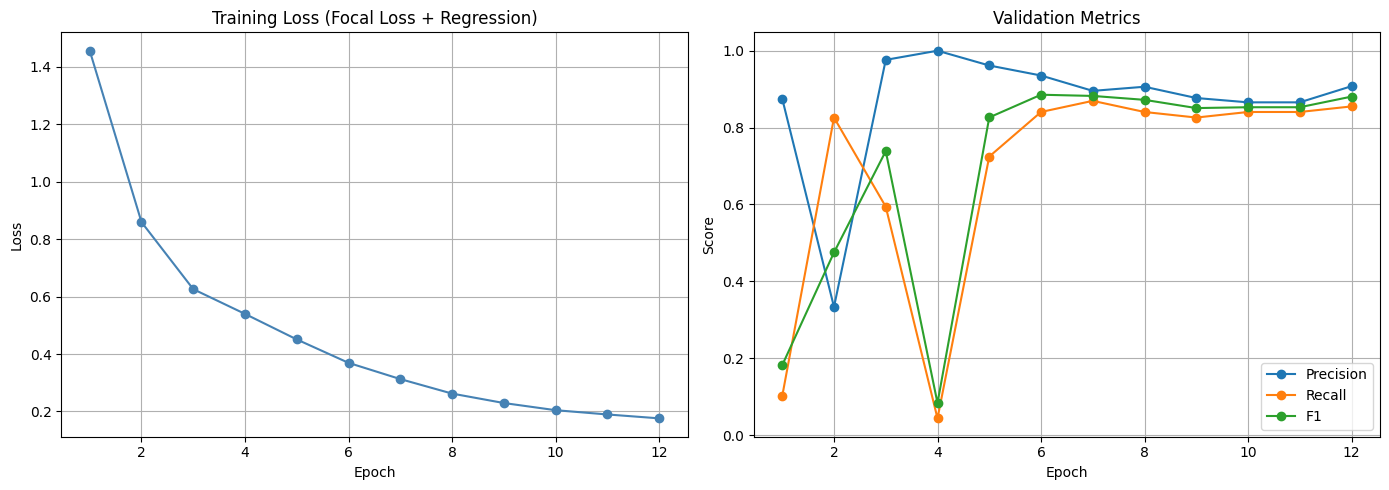

In [13]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss (Focal Loss + Regression)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(epochs, history["val_precision"], marker="o", label="Precision")
axes[1].plot(epochs, history["val_recall"], marker="o", label="Recall")
axes[1].plot(epochs, history["val_f1"], marker="o", label="F1")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 13. Evaluate on test set

In [14]:
# Rebuild architecture identically to training, then load weights.
best_model = retinanet_resnet50_fpn(weights=None, weights_backbone=None, min_size=512, max_size=512)

num_anchors = best_model.head.classification_head.num_anchors
in_channels = best_model.backbone.out_channels
best_model.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes,
)

# Match the inference-time thresholds used during training/val eval.
best_model.score_thresh = 0.5
best_model.nms_thresh = 0.5
best_model.detections_per_img = 100

best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.to(DEVICE)

test_metrics = evaluate_detector(best_model, test_loader, DEVICE, score_thresh=0.5, iou_thresh=0.5)
print("Test metrics:")
print(test_metrics)

Validation: 100%|██████████| 65/65 [00:07<00:00,  8.85it/s, precision=0.868, recall=0.831, f1=0.849]

Test metrics:
{'tp': 59, 'fp': 9, 'fn': 12, 'precision': 0.8676470588235294, 'recall': 0.8309859154929577, 'f1': 0.8489208633093526}


## 14. Visualize predictions

Green boxes = ground truth, Red boxes = model predictions with confidence scores.

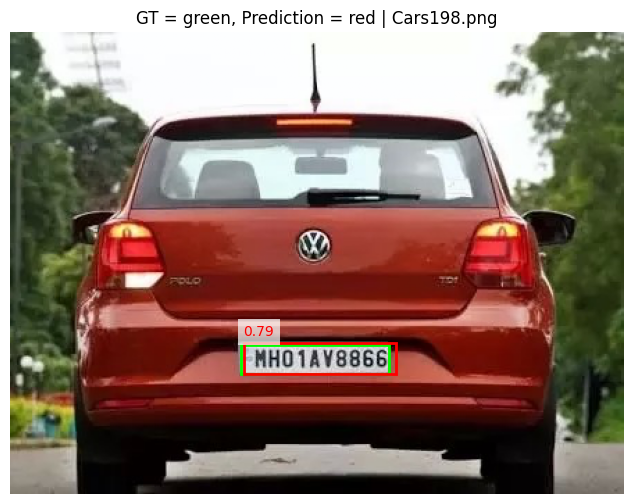

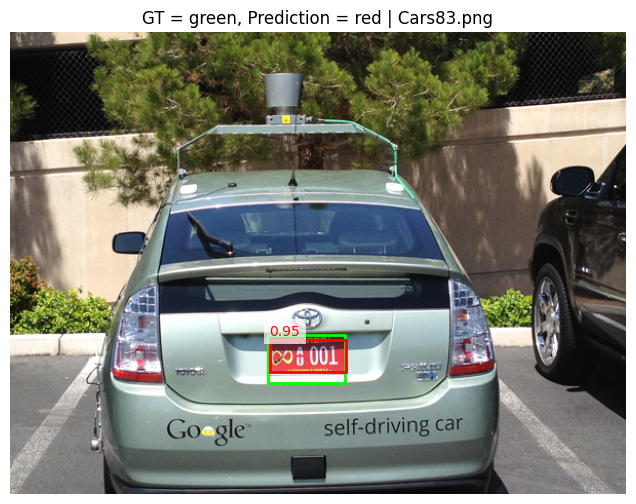

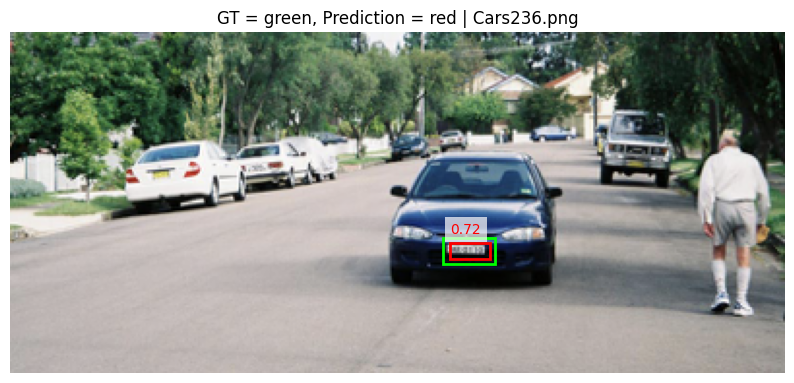

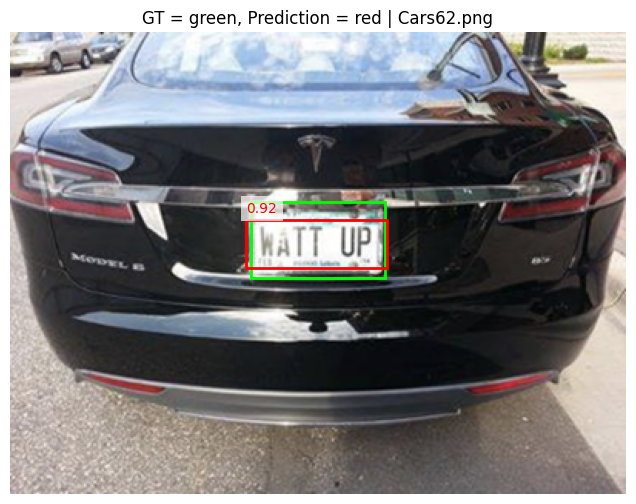

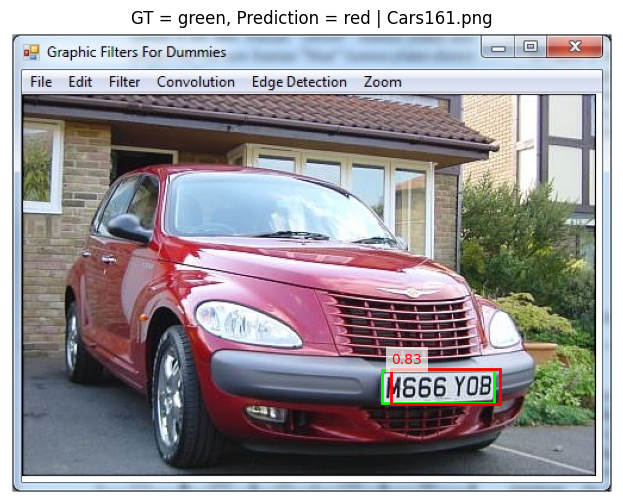

In [15]:
def visualize_predictions(model, dataset, device, num_images=5, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    with torch.no_grad():
        for idx in indices:
            image, target = dataset[idx]
            pred = model([image.to(device)])[0]

            img_np = image.permute(1, 2, 0).numpy()

            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            ax.imshow(img_np)

            for box in target["boxes"]:
                xmin, ymin, xmax, ymax = box.tolist()
                rect = patches.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    linewidth=2,
                    edgecolor="lime",
                    facecolor="none"
                )
                ax.add_patch(rect)

            for box, score in zip(pred["boxes"].cpu(), pred["scores"].cpu()):
                if score.item() < score_thresh:
                    continue

                xmin, ymin, xmax, ymax = box.tolist()
                rect = patches.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    linewidth=2,
                    edgecolor="red",
                    facecolor="none"
                )
                ax.add_patch(rect)

                ax.text(
                    xmin,
                    max(0, ymin - 5),
                    f"{score.item():.2f}",
                    color="red",
                    fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )

            ax.set_title(f"GT = green, Prediction = red | {dataset.file_list[idx]}")
            ax.axis("off")
            plt.show()

visualize_predictions(best_model, test_dataset, DEVICE, num_images=5, score_thresh=0.5)

## 15. Save metrics

In [16]:
results = {
    "model": "RetinaNet (ResNet-50 + FPN)",
    "loss_function": "Focal Loss (alpha=0.25, gamma=2.0) + Smooth L1",
    "best_val_f1": best_val_score,
    "history": history,
    "test_metrics": test_metrics,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "SGD (lr=0.0025, momentum=0.9, weight_decay=0.0005)",
    "lr_scheduler": "CosineAnnealingLR (T_max=NUM_EPOCHS)",
    "warmup_iters": WARMUP_ITERS,
    "grad_clip_max_norm": GRAD_CLIP_MAX_NORM,
    "score_thresh": 0.5,
    "nms_thresh": 0.5,
    "augmentation": "hflip + color jitter (train only)",
    "cls_head_bias_prior": 0.01,
    "seed": SEED
}

results_path = OUTPUT_DIR / "retinanet_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("Saved results to:", results_path)

Saved results to: /Users/macbook/Desktop/CMPS261_PlateDetection/retinanet_outputs/retinanet_results.json


## 16. Model summary and comparison notes

| Property | RetinaNet | Faster R-CNN | YOLOv8 |
|----------|-----------|--------------|--------|
| **Type** | One-stage | Two-stage | One-stage |
| **Anchor strategy** | Anchor-based (multi-scale, multi-aspect) | Anchor-based (RPN) | Anchor-free |
| **Loss function** | Focal Loss + Smooth L1 | Cross-Entropy + Smooth L1 | BCE + CIoU |
| **Backbone** | ResNet-50 + FPN | ResNet-50 + FPN | CSPDarknet |
| **Key innovation** | Focal Loss for class imbalance | Region Proposal Network | End-to-end anchor-free |

RetinaNet bridges the gap between one-stage speed and two-stage accuracy by using Focal Loss to address the foreground-background class imbalance that plagues one-stage detectors.